# Customer Health Score 3.0 - Analysis and Visuals
Use this notebook for exploratory analysis and business storytelling with charts.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
root = Path.cwd().parents[0]
processed = root / 'data' / 'processed'

health = pd.read_csv(processed / 'health_scores.csv')
value = pd.read_csv(processed / 'customer_value.csv')
actions = pd.read_csv(processed / 'customer_actions.csv')
scenarios = pd.read_csv(processed / 'campaign_scenarios.csv')
metrics = pd.read_csv(processed / 'model_metrics.csv')

## 1) Model quality

In [3]:
display(metrics)

,model,roc_auc,precision,recall,f1
0,random_forest,1.000000,1.0,1.000000,1.000000
1,logistic_regression,0.998864,1.0,0.970046,0.984795


## 2) Health score distribution

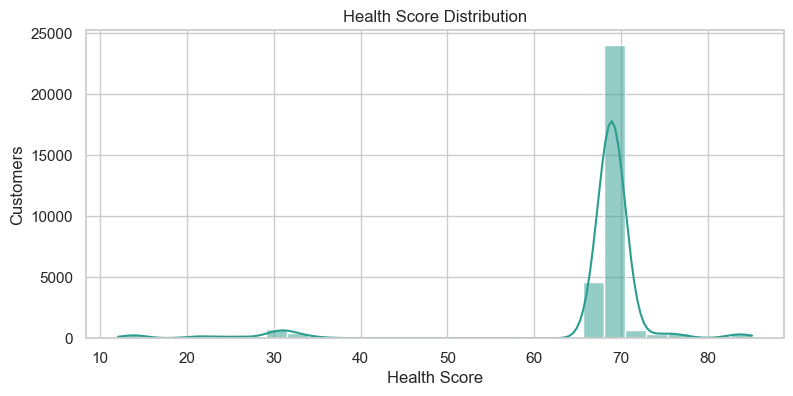

In [4]:
plt.figure(figsize=(9, 4))
sns.histplot(data=health, x='health_score', bins=30, kde=True, color='#2a9d8f')
plt.title('Health Score Distribution')
plt.xlabel('Health Score')
plt.ylabel('Customers')
plt.show()

In [ ]:
segment_counts = health['health_segment'].value_counts().reset_index()
segment_counts.columns = ['health_segment', 'customers']

plt.figure(figsize=(7, 4))
sns.barplot(data=segment_counts, x='health_segment', y='customers', palette='viridis')
plt.title('Customer Count by Health Segment')
plt.xlabel('Health Segment')
plt.ylabel('Customers')
plt.show()
display(segment_counts)

## 3) Economic impact

In [5]:
kpis = {
    'total_customers': int(health['customer_id'].nunique()),
    'expected_clv_saved': float(value['expected_clv_saved'].sum()),
    'expected_net_value': float(value['expected_net_value'].sum()),
    'avg_expected_roi': float(value['expected_roi'].mean()),
}
kpis

{'total_customers': 32718,
 'expected_clv_saved': 2823332.6789255654,
 'expected_net_value': 2156960.6789255654,
 'avg_expected_roi': 0.9786146514169268}

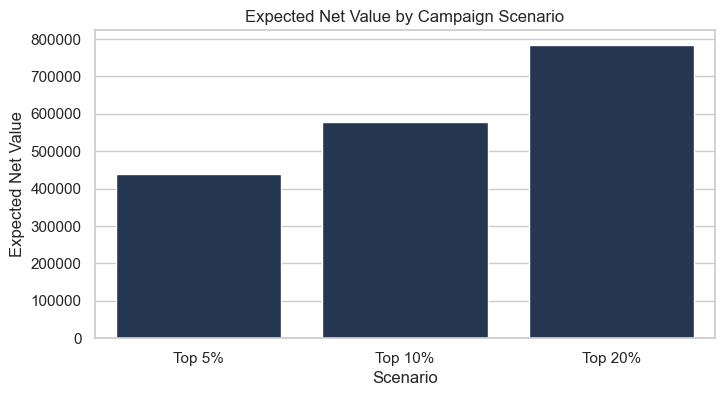

,scenario,customers_targeted,total_action_cost,expected_clv_saved,expected_net_value,avg_expected_roi,avg_churn_probability
0,Top 5%,108,5284.0,442666.02,438006.02,108.1210,1.0000
1,Top 10%,217,8759.0,587377.27,577812.27,68.1285,0.9995
2,Top 20%,434,15144.0,803364.67,784034.67,44.6235,0.9994


In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=scenarios, x='scenario', y='expected_net_value', color='#1d3557')
plt.title('Expected Net Value by Campaign Scenario')
plt.xlabel('Scenario')
plt.ylabel('Expected Net Value')
plt.show()
display(scenarios)

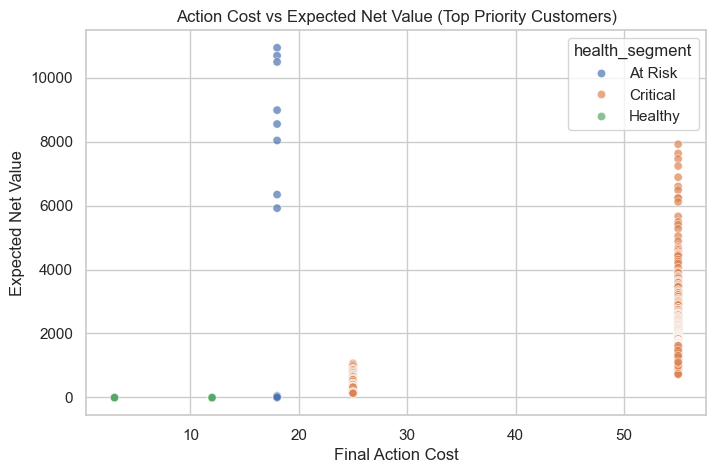

In [7]:
sample = actions.nlargest(3000, 'priority_score').copy()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x='final_action_cost',
    y='expected_net_value',
    hue='health_segment',
    alpha=0.7
)
plt.title('Action Cost vs Expected Net Value (Top Priority Customers)')
plt.xlabel('Final Action Cost')
plt.ylabel('Expected Net Value')
plt.show()

## 4) Action recommendations

In [ ]:
top_actions = (
    actions[[
        'customer_id',
        'health_segment',
        'next_best_action',
        'top_driver',
        'expected_net_value',
        'priority_score'
    ]]
    .sort_values('priority_score', ascending=False)
    .head(20)
)

display(top_actions)

,customer_id,health_segment,next_best_action,top_driver,expected_net_value,priority_score
0,TW-144768,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,10939.360000,0.967273
1,TW-115888,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,10692.693333,0.959381
2,TW-117242,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,10494.341310,0.953035
3,TW-117627,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,8987.743704,0.904832
4,TW-115911,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,8552.214394,0.890897
5,TW-116230,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,8038.720000,0.874468
6,TW-134104,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,6344.586667,0.820265
7,TW-122277,At Risk,Targeted retention offer,High churn probability; Low purchase recency; ...,5920.047273,0.806682
8,TW-132028,Critical,Executive retention outreach,High churn probability; Low purchase recency; ...,7921.335263,0.803440
9,TW-123287,Critical,Executive retention outreach,High churn probability; Low purchase recency; ...,7633.146667,0.794219


## 5) Advanced decision analysis
The following sections convert model outputs into strategic segments, budget simulations, and uncertainty-aware insights.

In [ ]:
analysis_df = actions.merge(
    value[['customer_id', 'retention_uplift_prob', 'intervention_cost']],
    on='customer_id',
    how='left'
 )

conditions = [
    (analysis_df['health_segment'].eq('Critical') & analysis_df['clv'].ge(analysis_df['clv'].quantile(0.75))),
    (analysis_df['health_segment'].eq('Critical')),
    (analysis_df['health_segment'].eq('At Risk') & analysis_df['sentiment_mean'].lt(-0.2)),
    (analysis_df['health_segment'].eq('At Risk')),
    (analysis_df['health_segment'].eq('Healthy') & analysis_df['expected_roi'].ge(analysis_df['expected_roi'].quantile(0.75)))
]

labels = [
    'Tier A Rescue (High CLV Critical)',
    'Tier B Rescue (Critical)',
    'Tier C Sentiment Recovery',
    'Tier D Retention Nurture',
    'Tier E Expansion'
 ]

analysis_df['strategic_segment'] = np.select(conditions, labels, default='Tier F Maintain')

strategic_summary = (
    analysis_df.groupby(['strategic_segment', 'next_best_action'], as_index=False)
    .agg(
        customers=('customer_id', 'count'),
        avg_churn_probability=('churn_probability', 'mean'),
        avg_expected_net_value=('expected_net_value', 'mean'),
        total_expected_net_value=('expected_net_value', 'sum'),
        avg_action_cost=('final_action_cost', 'mean')
    )
    .sort_values('total_expected_net_value', ascending=False)
)

display(strategic_summary.head(20))

In [ ]:
segment_heatmap = (
    analysis_df.groupby(['strategic_segment', 'score_confidence'], as_index=False)
    .agg(avg_expected_net_value=('expected_net_value', 'mean'))
)

pivot_heatmap = segment_heatmap.pivot(
    index='strategic_segment',
    columns='score_confidence',
    values='avg_expected_net_value'
).fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Average Expected Net Value by Strategic Segment and Confidence')
plt.xlabel('Score Confidence')
plt.ylabel('Strategic Segment')
plt.show()

In [ ]:
def simulate_budget_plan(df: pd.DataFrame, budget: float) -> dict:
    ranked = df[df['expected_net_value'] > 0].sort_values('priority_score', ascending=False).copy()
    ranked['cum_cost'] = ranked['final_action_cost'].cumsum()
    selected = ranked[ranked['cum_cost'] <= budget]

    return {
        'budget': budget,
        'customers_targeted': int(len(selected)),
        'total_action_cost': float(selected['final_action_cost'].sum()),
        'expected_clv_saved': float(selected['expected_clv_saved'].sum()),
        'expected_net_value': float(selected['expected_net_value'].sum()),
        'avg_expected_roi': float(selected['expected_roi'].mean()) if len(selected) else 0.0
    }

budgets = [5000, 10000, 25000, 50000, 100000]
budget_results = pd.DataFrame([simulate_budget_plan(analysis_df, b) for b in budgets])
display(budget_results)

plt.figure(figsize=(9, 4))
sns.lineplot(data=budget_results, x='budget', y='expected_net_value', marker='o', color='#264653')
plt.title('Budget Simulator: Expected Net Value vs Budget')
plt.ylabel('Expected Net Value')
plt.xlabel('Budget')
plt.show()

In [ ]:
rng = np.random.default_rng(42)
bootstrap_runs = 400
records = []

for confidence, group in analysis_df.groupby('score_confidence'):
    values = group['expected_net_value'].to_numpy()
    if len(values) == 0:
        continue

    samples = [
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(bootstrap_runs)
    ]
    records.append({
        'score_confidence': confidence,
        'mean_expected_net_value': float(np.mean(values)),
        'ci_low_95': float(np.percentile(samples, 2.5)),
        'ci_high_95': float(np.percentile(samples, 97.5)),
        'customers': int(len(values))
    })

uncertainty_df = pd.DataFrame(records).sort_values('mean_expected_net_value', ascending=False)
display(uncertainty_df)

plt.figure(figsize=(8, 4))
plt.errorbar(
    x=uncertainty_df['score_confidence'],
    y=uncertainty_df['mean_expected_net_value'],
    yerr=[
        uncertainty_df['mean_expected_net_value'] - uncertainty_df['ci_low_95'],
        uncertainty_df['ci_high_95'] - uncertainty_df['mean_expected_net_value']
    ],
    fmt='o',
    capsize=6
 )
plt.title('Uncertainty by Confidence Bucket (95% bootstrap CI)')
plt.xlabel('Score Confidence')
plt.ylabel('Expected Net Value (mean)')
plt.show()

In [ ]:
action_mix = (
    analysis_df.groupby('next_best_action', as_index=False)
    .agg(
        customers=('customer_id', 'count'),
        total_expected_net_value=('expected_net_value', 'sum'),
        avg_expected_roi=('expected_roi', 'mean')
    )
    .sort_values('total_expected_net_value', ascending=False)
)

display(action_mix)

plt.figure(figsize=(10, 4))
sns.barplot(data=action_mix, x='next_best_action', y='total_expected_net_value', color='#2a9d8f')
plt.title('Total Expected Net Value by Action Type')
plt.xlabel('Action Type')
plt.ylabel('Total Expected Net Value')
plt.xticks(rotation=20, ha='right')
plt.show()

summary_lines = [
    f"Top strategic segment: {strategic_summary.iloc[0]['strategic_segment']}",
    f"Best budget plan by net value: {int(budget_results.sort_values('expected_net_value', ascending=False).iloc[0]['budget'])}",
    f"Most valuable action: {action_mix.iloc[0]['next_best_action']}"
]

print('Executive Summary')
for line in summary_lines:
    print(f'- {line}')